---
title: Water level measurement timeseries Lago di Santa Giustina
subtitle: Timeseries of water level measurements at Lago di Santa Giustina, Italy
authors:
  - name: Juraj Zvolenský
    orcid: 0009-0000-9185-7955
    github: jzvolensky
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
  - name: Michele Claus
    orcid: 0000-0003-3680-381X
    github: clausmichele
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
date: 2025-10-02
thumbnail: https://raw.githubusercontent.com/EOPF-Sample-Service/eopf-sample-notebooks/refs/heads/main/notebooks/static/ESA_logo_2020_Deep.png
keywords: ["earth observation", "remote sensing", "water level", "timeseries", "lake", "Italy"]
tags: ["notebook", "data", "timeseries", "water level", "lake"]
releaseDate:  2025-10-02
datePublished:  2025-10-02
dateModified:  2025-10-02
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

```{image} ../static/ESA_EOPF_logo_2025_COLOR_ESA_blue_reduced.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```

## Table of contents

- [Introduction](#Introduction)
- [Setup](#Setup)
- [Read EOPF-Zarr](#Read-EOPF-Zarr)

(Introduction_water)=
## Introduction

This notebook demonstrates how to read and visualize water level measurements at Lago di Santa Giustina, Italy, using data stored in EOPF-Zarr format. 

The water level timeseries data is derived from the Sentinel-2 imagery.

The workflow demonstrates how to:
- Access the EOPF Zarr data
- Filter the data so that only almost cloud-free observations are retained
- Calculate NDWI (Normalized Difference Water Index)
- Extract water level measurements using skimage's otsu_threshold method
- Visualize the water level timeseries

## The lake

Lago di Santa Giustina is an artificial lake located in the Trentino region of northern Italy. It was created in the 1950s by damming the Noce River for hydroelectric power generation. The lake is situated at an elevation of approximately 500 meters above sea level and has a surface area of about 3.5 square kilometers.

![Lago di Santa Giustina](../static/lago-santa-gustina.png)

Image source: [Valentina Martini, I love Val di Non](https://www.ilovevaldinon.it/lago-di-santa-giustina)

:::{hint} Overview

**Questions**
- How can we detect water bodies using Sentinel-2 imagery?
- How can we extract water level measurements from EOPF-Zarr data?
- How can we visualize the water level timeseries?

**Objectives**
- Detect the water body
- Extract water level measurements
- Visualize the water level timeseries

:::

(Setup_water)=
## Setup
Start importing the necessary libraries

In [20]:
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pystac_client
from pystac_client import CollectionSearch
from rasterio.features import geometry_mask

from skimage.filters import threshold_otsu

from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
from pyproj import Transformer
from concurrent.futures import as_completed

from distributed import LocalCluster

In [ ]:
cluster = LocalCluster(processes=False)
client = cluster.get_client()
cluster

'0.3.0'

In [ ]:
sample_geojson = "./urban.geojson"

geojson = gpd.read_file(sample_geojson)

bbox = geojson.total_bounds

Bounding Box: [11.31984491 46.47249719 11.3595797  46.5004805 ]


In [ ]:
# TODO: Use this once the data has been reprocessed

# from xcube.core.store import new_data_store
# from xcube_eopf.utils import reproject_bbox
# store = new_data_store("eopf-zarr")

# bbox=[11.003288060439315, 46.34055268553584, 11.10369555555596, 46.40183319621778] # or bbox
# crs_utm = "EPSG:32632"
# bbox_utm = reproject_bbox(bbox, "EPSG:4326", crs_utm)
# ds = store.open_data(
#     data_id="sentinel-2-l2a",
#     bbox=bbox_utm,
#     time_range=["2022-12-31", "2024-01-01"],
#     spatial_res=10,
#     crs=crs_utm,
#     variables=[
#         "b04",
#         "b03",
#         "b02",
#         "b08",
#     ],
# )
# ds

KeyError: 'grid:code'

In [3]:
search = CollectionSearch(
    url="https://stac.core.eopf.eodc.eu/collections",
)
for collection_dict in search.collections_as_dicts():
    print(collection_dict["id"])

sentinel-2-l2a
sentinel-3-olci-l2-lfr
sentinel-1-l2-ocn
sentinel-3-slstr-l2-lst
sentinel-1-l1-grd
sentinel-2-l1c
sentinel-1-l1-slc
sentinel-3-slstr-l1-rbt
sentinel-3-olci-l1-efr
sentinel-3-olci-l1-err
sentinel-3-olci-l2-lrr


In [4]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=[
            11.003288060439315,
            46.34055268553584,
            11.10369555555596,
            46.40183319621778,
        ],
        datetime=["2020-12-31", "2024-01-01"],
    ).items()
)
print(f"items found: {len(items)}")

items found: 434


In [6]:
def reproject_bbox(bbox, src_crs="EPSG:4326", dst_crs="EPSG:32632"):
    transformer = Transformer.from_crs(src_crs, dst_crs, always_xy=True)
    xmin, ymin = transformer.transform(bbox[0], bbox[1])
    xmax, ymax = transformer.transform(bbox[2], bbox[3])
    return [xmin, ymin, xmax, ymax]


bbox = [11.003288060439315, 46.34055268553584, 11.10369555555596, 46.40183319621778]


def load_tile(item, bbox_ll):
    href = item.assets["product"].href
    ds = xr.open_datatree(href, engine="zarr", chunks={}, mask_and_scale=True)

    dst_crs = item.properties.get("proj:code")
    if dst_crs is None:
        raise ValueError(f"No proj:code in item {item.id}")

    utm_bbox = reproject_bbox(bbox_ll, dst_crs=dst_crs)

    # 20m reflectance bands
    ds_ref = (
        ds["measurements"]["reflectance"]["r20m"]
        .ds.sel(x=slice(utm_bbox[0], utm_bbox[2]), y=slice(utm_bbox[3], utm_bbox[1]))
        .expand_dims(time=[item.datetime])
    )

    ds_scl = (
        ds["conditions"]["mask"]["l2a_classification"]["r20m"]
        .ds.sel(x=slice(utm_bbox[0], utm_bbox[2]), y=slice(utm_bbox[3], utm_bbox[1]))
        .expand_dims(time=[item.datetime])
    )

    return ds_ref, ds_scl


results = []
with ThreadPoolExecutor(max_workers=8) as ex:
    futures = [ex.submit(load_tile, item, bbox) for item in items]
    for f in tqdm(as_completed(futures), total=len(futures), desc="Loading tiles"):
        results.append(f.result())

r20m_datasets, scl_datasets = zip(*results)

r20m = xr.concat(r20m_datasets, dim="time")
scl_cube = xr.concat(scl_datasets, dim="time")
datacube = xr.merge([r20m, scl_cube]).sortby("time")

datacube

Loading tiles:   0%|          | 0/434 [00:00<?, ?it/s]

Loading tiles: 100%|██████████| 434/434 [02:29<00:00,  2.90it/s]


<xarray.Dataset> Size: 5GB
Dimensions:  (time: 434, y: 350, x: 377)
Coordinates:
  * time     (time) object 3kB 1609496609024000000 ... 1703844871024000000
  * x        (x) float32 2kB 6.542e+05 6.542e+05 ... 6.617e+05 6.617e+05
  * y        (y) float32 1kB 5.141e+06 5.141e+06 ... 5.134e+06 5.134e+06
Data variables:
    b01      (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b02      (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b03      (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b04      (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b05      (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b06      (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b07      (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b11      (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b12      (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b8a      (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    scl      (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>

In [ ]:
# Get CRS from STAC item
crs = items[0].properties.get("proj:code")
print("CRS:", crs)
# assign to datacube
datacube = datacube.rio.write_crs(crs, inplace=True)

CRS: EPSG:32632


In [9]:
# Open and align lake geojson
lake_gdf = gpd.read_file("lago_santa_giustina.geojson")
lake_gdf = lake_gdf.to_crs(crs)

## Visualize datacube sample

In this section we visualize an RGB composite for a random date and use the lake polygon as an outline to see if it is aligned correctly.


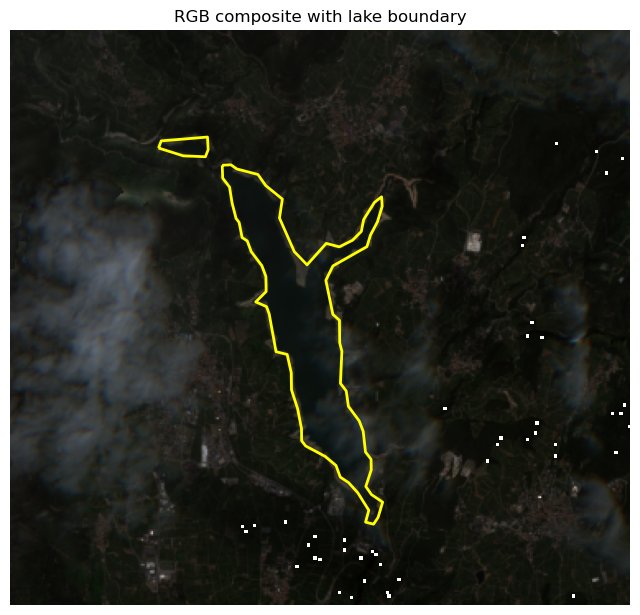

/home/jzvolensky/miniconda3/envs/eopf-zarr/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/jzvolensky/miniconda3/envs/eopf-zarr/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)


In [ ]:
datacube_sample = datacube.isel(time=50)

rgb = xr.concat(
    [datacube_sample["b04"], datacube_sample["b03"], datacube_sample["b02"]], dim="band"
)
rgb = rgb.assign_coords(band=["red", "green", "blue"])

rgb_norm = (rgb - rgb.min()) / (rgb.max() - rgb.min())

rgb_img = rgb_norm.transpose("y", "x", "band").values

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(
    rgb_img,
    extent=[
        float(rgb.x.min()),
        float(rgb.x.max()),
        float(rgb.y.min()),
        float(rgb.y.max()),
    ],
)

lake_gdf.boundary.plot(ax=ax, edgecolor="yellow", linewidth=2)

ax.set_title("RGB composite with lake boundary")
ax.axis("off")
plt.show()

## Cloud masking

In this section we apply the `scl` band to mask out the clouds. We visualize the same RGB composite as before, but with the mask applied.

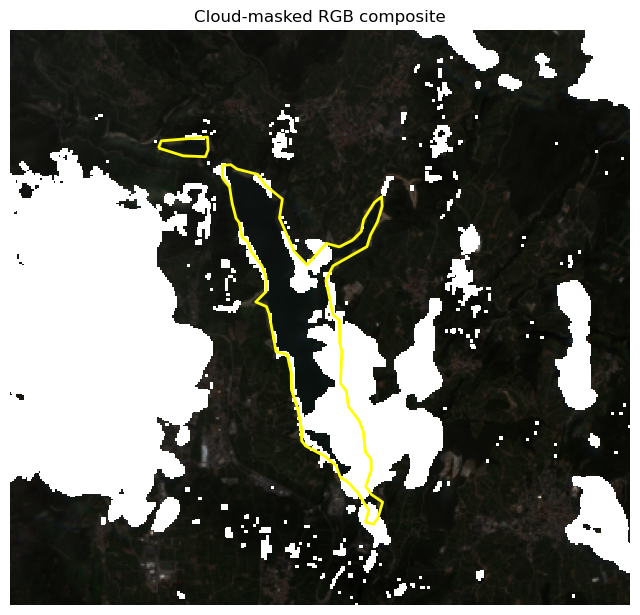

In [11]:
valid_classes = [2, 4, 5, 6]

mask = datacube["scl"].isin(valid_classes)

datacube_masked = datacube.where(mask)

datacube_sample = datacube_masked.isel(time=50)

rgb = xr.concat(
    [datacube_sample["b04"], datacube_sample["b03"], datacube_sample["b02"]], dim="band"
)
rgb = rgb.assign_coords(band=["red", "green", "blue"])

rgb_norm = (rgb - rgb.min()) / (rgb.max() - rgb.min())

rgb_img = rgb_norm.transpose("y", "x", "band").values

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(
    rgb_img,
    extent=[
        float(rgb.x.min()),
        float(rgb.x.max()),
        float(rgb.y.min()),
        float(rgb.y.max()),
    ],
)
lake_gdf.boundary.plot(ax=ax, edgecolor="yellow", linewidth=2)
ax.set_title("Cloud-masked RGB composite")
ax.axis("off")
plt.show()

In [12]:
valid_classes = [4, 5, 6]
lake_mask = datacube["scl"].rio.clip(lake_gdf.geometry, lake_gdf.crs)

clear_mask = lake_mask.isin(valid_classes)

clear_fraction = clear_mask.mean(dim=("y", "x")).compute()  # values 0–1

threshold = 0.05
good_times = clear_fraction.time[clear_fraction >= threshold]

datacube_clear = datacube.where(clear_fraction >= threshold, drop=True)

datacube_clear

<xarray.Dataset> Size: 3GB
Dimensions:      (time: 256, y: 350, x: 377)
Coordinates:
  * time         (time) object 2kB 1610100799024000000 ... 1702980871024000000
  * x            (x) float32 2kB 6.542e+05 6.542e+05 ... 6.617e+05 6.617e+05
  * y            (y) float32 1kB 5.141e+06 5.141e+06 ... 5.134e+06 5.134e+06
    spatial_ref  int64 8B 0
Data variables:
    b01          (time, y, x) float64 270MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b02          (time, y, x) float64 270MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b03          (time, y, x) float64 270MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b04          (time, y, x) float64 270MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b05          (time, y, x) float64 270MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b06          (time, y, x) float64 270MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b07          (time, y, x) float64 270MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b11          (time, y, x) float64 270MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b12          (time, y, x) float64 270MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b8a          (time, y, x) float64 270MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    scl          (time, y, x) float64 270MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>

## NDWI

Water detection is performed using the Normalized Difference Water Index (NDWI), which utilizes the green and near-infrared (NIR) bands of the Sentinel-2 imagery. The NDWI is calculated as follows:

NDWI = (Green - NIR) / (Green + NIR)


In [16]:
ndwi = (datacube_clear["b03"] - datacube_clear["b8a"]) / (
    datacube_clear["b03"] + datacube_clear["b8a"]
)

In [ ]:
def detect_water(ndwi_array):
    """Return binary mask where water=1, keeping xarray coords."""
    masks = []

    for i in range(ndwi_array.time.size):
        arr = ndwi_array.isel(time=i).values
        arr = np.nan_to_num(arr, nan=-10.0)

        if np.all(arr == arr.flat[0]):
            masks.append(np.zeros_like(arr, dtype=bool))
            continue

        try:
            thr = threshold_otsu(arr)
        except Exception:
            thr = -1

        masks.append(arr > thr)

    mask_array = xr.DataArray(
        np.stack(masks, axis=0),
        coords=ndwi_array.coords,
        dims=ndwi_array.dims,
        name="water_mask",
    )
    return mask_array


water_masks = detect_water(ndwi)

/home/jzvolensky/miniconda3/envs/eopf-zarr/lib/python3.11/site-packages/skimage/exposure/exposure.py:307: RuntimeWarning: overflow encountered in add
  bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
/home/jzvolensky/miniconda3/envs/eopf-zarr/lib/python3.11/site-packages/skimage/filters/thresholding.py:396: RuntimeWarning: overflow encountered in multiply
  mean1 = np.cumsum(counts * bin_centers) / weight1
/home/jzvolensky/miniconda3/envs/eopf-zarr/lib/python3.11/site-packages/skimage/filters/thresholding.py:396: RuntimeWarning: invalid value encountered in multiply
  mean1 = np.cumsum(counts * bin_centers) / weight1
/home/jzvolensky/miniconda3/envs/eopf-zarr/lib/python3.11/site-packages/skimage/filters/thresholding.py:397: RuntimeWarning: overflow encountered in multiply
  mean2 = (np.cumsum((counts * bin_centers)[::-1]) / weight2[::-1])[::-1]
/home/jzvolensky/miniconda3/envs/eopf-zarr/lib/python3.11/site-packages/skimage/filters/thresholding.py:397: RuntimeWarning: invalid value

In [ ]:
lake_masked = []

for t in range(len(datacube_clear.time)):
    wm = xr.DataArray(
        water_masks[t],
        dims=("y", "x"),
        coords={"y": datacube_clear.y, "x": datacube_clear.x},
        name="water_mask",
    ).rio.write_crs(datacube_clear.rio.crs)

    mask = geometry_mask(
        [lake_gdf.geometry.unary_union],
        transform=wm.rio.transform(),
        invert=True,  # True = keep inside
        out_shape=wm.shape,
    )
    wm_clipped = wm.where(mask)  # set outside polygon to NaN
    lake_masked.append(wm_clipped)

water_masks_clipped = xr.concat(lake_masked, dim="time")
print((water_masks_clipped == 1).sum(dim=("y", "x")).isel(time=0).values)

/tmp/ipykernel_2107392/65786403.py:14: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  [lake_gdf.geometry.unary_union],
/tmp/ipykernel_2107392/65786403.py:14: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  [lake_gdf.geometry.unary_union],
/tmp/ipykernel_2107392/65786403.py:14: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  [lake_gdf.geometry.unary_union],
/tmp/ipykernel_2107392/65786403.py:14: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  [lake_gdf.geometry.unary_union],
/tmp/ipykernel_2107392/65786403.py:14: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  [lake_gdf.geometry.unary_union],
/tmp/ipykernel_2107392/65786403.py:14: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' m

6901


In [21]:
water_fraction = water_masks_clipped.sum(dim=("y", "x")) / (
    water_masks_clipped.notnull().sum(dim=("y", "x"))
)

In [22]:
import pandas as pd

df_water = pd.DataFrame(
    {"time": water_fraction.time.values, "water_fraction": water_fraction.values}
)
df_water.set_index("time", inplace=True)
print(df_water.head())

      water_fraction
time                
0           0.987268
1           0.985837
2           0.865951
3           0.819742
4           0.931474


In [23]:
pixel_area_m2 = 20 * 20

water_pixel_count = (water_masks_clipped == 1).sum(dim=("y", "x"))
water_area_m2 = water_pixel_count * pixel_area_m2

water_area_m2 = water_area_m2.assign_coords(time=water_masks_clipped.time)

dates = pd.to_datetime(water_masks.time.values)

water_area_ts = pd.Series(water_area_m2.values, index=dates)

In [38]:
print(water_area_m2.time)

<xarray.DataArray 'time' (time: 256)> Size: 2kB
array([  0,   1,   2, ..., 253, 254, 255])
Coordinates:
    spatial_ref  int64 8B 0
  * time         (time) int64 2kB 0 1 2 3 4 5 6 ... 249 250 251 252 253 254 255


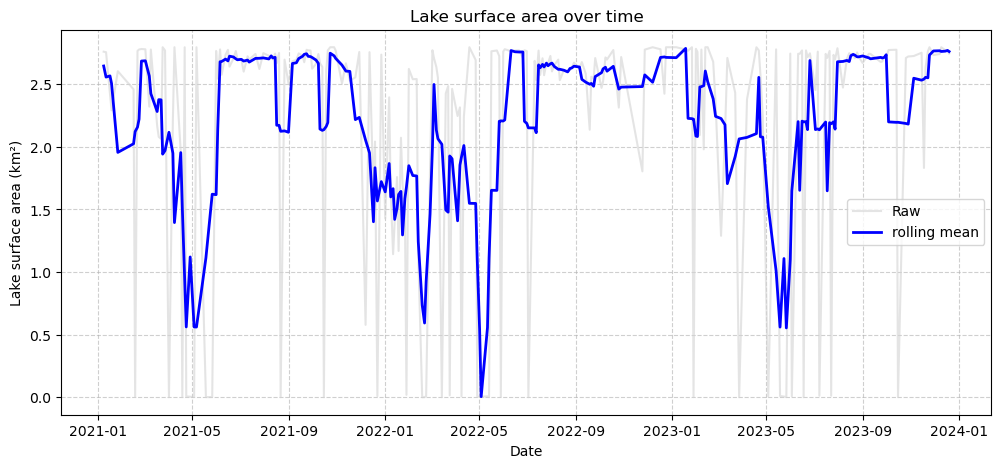

In [24]:
smoothed = water_area_ts.rolling(window=5, center=True, min_periods=1).mean()

plt.figure(figsize=(12, 5))
plt.plot(
    water_area_ts.index,
    water_area_ts.values / 1e6,
    color="lightgray",
    alpha=0.6,
    label="Raw",
)
plt.plot(
    smoothed.index,
    smoothed.values / 1e6,
    color="blue",
    linewidth=2,
    label="rolling mean",
)
plt.ylabel("Lake surface area (km²)")
plt.xlabel("Date")
plt.title("Lake surface area over time")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

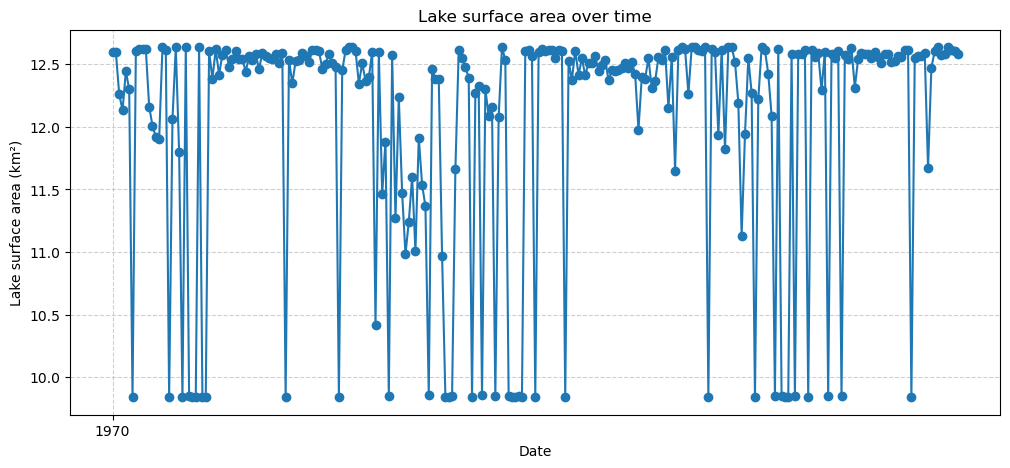

In [ ]:
pixel_area_m2 = 20 * 20

pixel_count = (~np.isnan(water_masks_clipped)).sum(dim=("y", "x"))

water_area_m2 = water_fraction * pixel_count * pixel_area_m2

water_area_ts = pd.Series(
    water_area_m2.values, index=pd.to_datetime(water_area_m2.time.values)
)

plt.figure(figsize=(12, 5))
plt.plot(water_area_ts.index, water_area_ts.values / 1e6, marker="o", linestyle="-")
plt.ylabel("Lake surface area (km²)")
plt.xlabel("Date")
plt.title("Lake surface area over time")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [ ]:
def compute_rgb(dataset):
    b02 = dataset["b02"]
    b03 = dataset["b03"]
    b04 = dataset["b04"]

    rgb = np.stack([b04, b03, b02], axis=-1)

    rgb = (rgb / 0.25).clip(0, 1)

    plt.figure(figsize=(10, 10))
    plt.imshow(rgb, origin="upper")
    plt.title("RGB composite")
    plt.axis("off")
    plt.show()


compute_rgb(datacube.isel(time=10))

In [ ]:
ndwi = (datacube["b03"] - datacube["b8a"]) / (datacube["b03"] + datacube["b8a"])
ndwi

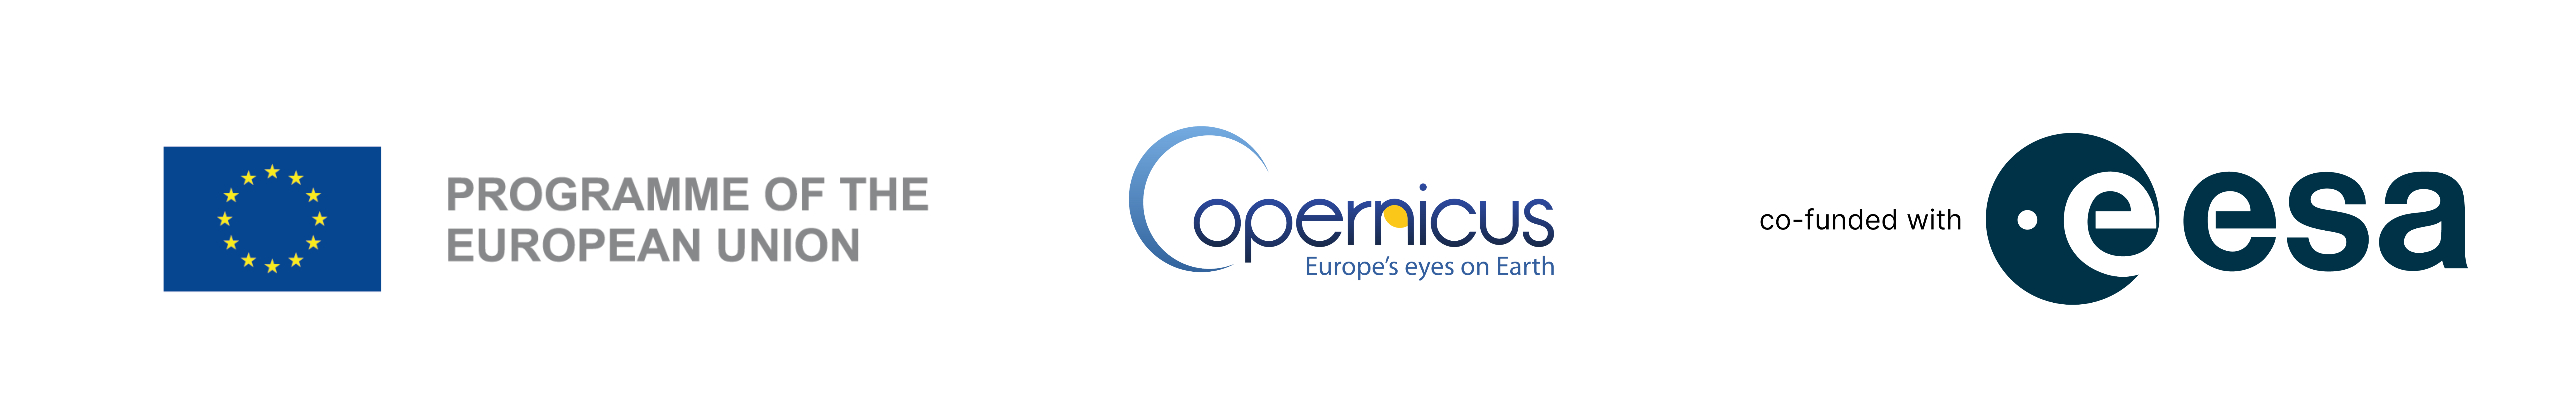